# GARCH(1,1) 예측 가능성 분석
## PBR 1Y Z-Score Std (3MA) & MOM 1Y Z-Score Std (3MA)

### 분석 목적
- 섹터 간 PBR/MOM Z-Score의 **횡단면 표준편차(분산도)**의 21일 이동평균이 GARCH(1,1)로 모델링 가능한지 검증
- 일별 데이터는 노이즈가 심해 큰 추세(변동성 레짐)를 포착하기 어려움 → 3MA로 스무딩 후 GARCH 적용
- 분산도가 높다 = 섹터 간 밸류에이션/모멘텀 격차가 크다 → 시장 스트레스 또는 로테이션 기회

### 분석 순서
1. 데이터 로드 및 시리즈 생성 (raw Std → 3MA 적용)
2. 탐색적 분석 (EDA) — raw vs 3MA 비교, 정상성 검정
3. ARCH 효과 검정 (3MA 시리즈 기준)
4. GARCH(1,1) 모델 적합
5. 롤링 예측 & 큰 추세 포착 성과 평가

## 0. 패키지 설치 및 임포트

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "arch", "statsmodels", "-q"], check=True)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


CompletedProcess(args=['/usr/local/python/3.12.1/bin/python3', '-m', 'pip', 'install', 'arch', 'statsmodels', '-q'], returncode=0)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False

BASE_DIR = Path(".")
PBR_PATH  = BASE_DIR / "krx_sector_pbr.csv"
PRICE_PATH = BASE_DIR / "kodex_sector_etf_close.csv"
BENCHMARK_LABEL = "섹터평균"
SECTOR_ALIAS_MAP = {"IT": "정보기술", "K콘텐츠": "K콘텐츠"}

print("임포트 완료")

임포트 완료


## 1. 데이터 로드 & 시리즈 생성

In [3]:
def normalize_sector_name(name: str) -> str:
    s = str(name).strip()
    s = re.sub(r"^KODEX\s+", "", s)
    s = re.sub(r"^KRX\s+", "", s)
    s = re.sub(r"\s+", "", s)
    return SECTOR_ALIAS_MAP.get(s, s)

def rolling_zscore(data: pd.DataFrame, window: int) -> pd.DataFrame:
    mean = data.rolling(window=window, min_periods=1).mean()
    std  = data.rolling(window=window, min_periods=1).std()
    return (data - mean) / (std + 1e-10)

# --- 로드 ---
pbr_df   = pd.read_csv(PBR_PATH,   parse_dates=["날짜"])
price_df = pd.read_csv(PRICE_PATH, parse_dates=["날짜"])

# --- 전처리 ---
pbr_daily = (
    pbr_df.rename(columns={"날짜": "date"})
    .sort_values("date").set_index("date")
    .rename(columns=normalize_sector_name)
)
price_daily = (
    price_df.rename(columns={"날짜": "date"})
    .sort_values("date").set_index("date")
    .rename(columns=normalize_sector_name)
)

common_sectors = sorted(set(pbr_daily.columns) & set(price_daily.columns))
common_dates   = pbr_daily.index.intersection(price_daily.index)
pbr_daily   = pbr_daily.loc[common_dates, common_sectors]
price_daily = price_daily.loc[common_dates, common_sectors]

print(f"공통 섹터 수 : {len(common_sectors)}")
print(f"데이터 기간  : {common_dates.min().date()} ~ {common_dates.max().date()} ({len(common_dates)}일)")
print(f"섹터 목록    : {common_sectors}")

공통 섹터 수 : 15
데이터 기간  : 2010-01-04 ~ 2026-03-30 (3995일)
섹터 목록    : ['K콘텐츠', '건설', '경기소비재', '기계장비', '반도체', '보험', '에너지화학', '운송', '은행', '자동차', '정보기술', '증권', '철강', '필수소비재', '헬스케어']


In [4]:
# --- 1Y Z-Score 계산 (252 거래일) ---
WINDOW = 252

pbr_z = rolling_zscore(pbr_daily, WINDOW)

# 252일 누적 수익률(1Y MOM)을 매일 계산 → 1Y Z-Score
mom_1y_ret = price_daily.pct_change(252) * 100
mom_z = rolling_zscore(mom_1y_ret, WINDOW)

# 섹터평균 벤치마크 컬럼 제외
sectors = [c for c in common_sectors if c != BENCHMARK_LABEL]

# Cross-sectional Std (원본)
pbr_std_raw = pbr_z[sectors].std(axis=1).rename("pbr_std_raw")
mom_std_raw = mom_z[sectors].std(axis=1).rename("mom_std_raw")

# 3MA 스무딩 → GARCH 분석 대상
pbr_std = pbr_std_raw.rolling(window=3, min_periods=1).mean().rename("pbr_std_21ma")
mom_std = mom_std_raw.rolling(window=3, min_periods=1).mean().rename("mom_std_21ma")

# 초기 WINDOW*2 기간 제거 (Z-Score + pct_change(252) 안정화)
pbr_std_raw = pbr_std_raw.iloc[WINDOW * 2:]
mom_std_raw = mom_std_raw.iloc[WINDOW * 2:]
pbr_std     = pbr_std.iloc[WINDOW * 2:]
mom_std     = mom_std.iloc[WINDOW * 2:]

print("시리즈 생성 완료")
print(f"기간: {pbr_std.index.min().date()} ~ {pbr_std.index.max().date()}, n={len(pbr_std)}")
print()
print(pbr_std.describe().rename("PBR Std 3MA").to_frame()
      .join(mom_std.describe().rename("MOM Std 3MA")))

시리즈 생성 완료
기간: 2012-01-09 ~ 2026-03-30, n=3491

       PBR Std 3MA  MOM Std 3MA
count  3491.000000  3491.000000
mean      1.150209     1.003780
std       0.318093     0.340433
min       0.458128     0.186666
25%       0.944654     0.769739
50%       1.137403     1.001533
75%       1.342148     1.239068
max       2.547633     1.949794


## 2. 탐색적 분석 (EDA)

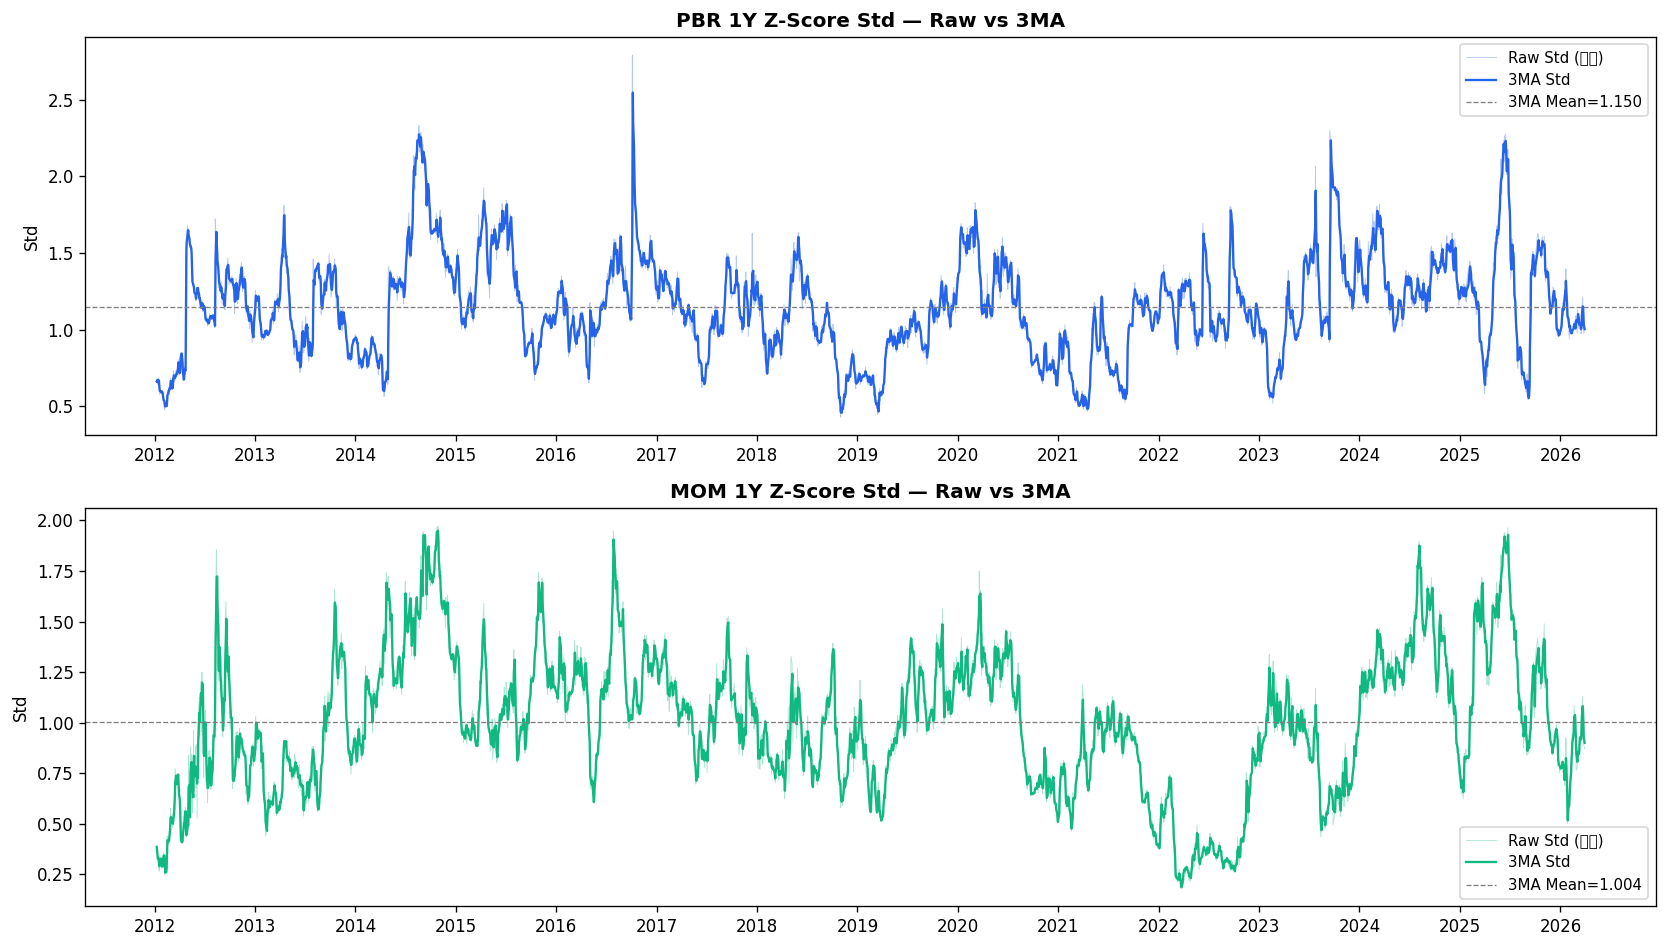

In [5]:
# raw Std vs 3MA 비교 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, raw, ma, color, label in zip(
    axes,
    [pbr_std_raw, mom_std_raw],
    [pbr_std,     mom_std],
    ["#2563eb",   "#10b981"],
    ["PBR",       "MOM"],
):
    ax.plot(raw.index, raw.values, linewidth=0.5, color=color, alpha=0.35, label="Raw Std (일별)")
    ax.plot(ma.index,  ma.values,  linewidth=1.4, color=color, label="3MA Std")
    ax.axhline(ma.mean(), color="gray", linestyle="--", linewidth=0.8, label=f"3MA Mean={ma.mean():.3f}")
    ax.set_title(f"{label} 1Y Z-Score Std — Raw vs 3MA", fontsize=12, fontweight="bold")
    ax.set_ylabel("Std")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

In [6]:
# ADF 정상성 검정 (3MA 시리즈 기준)
def adf_report(series: pd.Series, name: str) -> None:
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"[{name}]")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}  {'→ 정상 (단위근 기각)' if result[1] < 0.05 else '→ 비정상 (단위근 존재)'}")
    print(f"  Critical 1%   : {result[4]['1%']:.4f}")
    print(f"  Critical 5%   : {result[4]['5%']:.4f}")
    print()

adf_report(pbr_std, "PBR Std 3MA (원본)")
adf_report(mom_std, "MOM Std 3MA (원본)")
adf_report(pbr_std.diff().dropna(), "PBR Std 3MA (1차 차분)")
adf_report(mom_std.diff().dropna(), "MOM Std 3MA (1차 차분)")

[PBR Std 3MA (원본)]
  ADF Statistic : -6.0682
  p-value       : 0.0000  → 정상 (단위근 기각)
  Critical 1%   : -3.4322
  Critical 5%   : -2.8624

[MOM Std 3MA (원본)]
  ADF Statistic : -4.4754
  p-value       : 0.0002  → 정상 (단위근 기각)
  Critical 1%   : -3.4322
  Critical 5%   : -2.8624



[PBR Std 3MA (1차 차분)]
  ADF Statistic : -11.3270
  p-value       : 0.0000  → 정상 (단위근 기각)
  Critical 1%   : -3.4322
  Critical 5%   : -2.8624

[MOM Std 3MA (1차 차분)]
  ADF Statistic : -11.6999
  p-value       : 0.0000  → 정상 (단위근 기각)
  Critical 1%   : -3.4322
  Critical 5%   : -2.8624



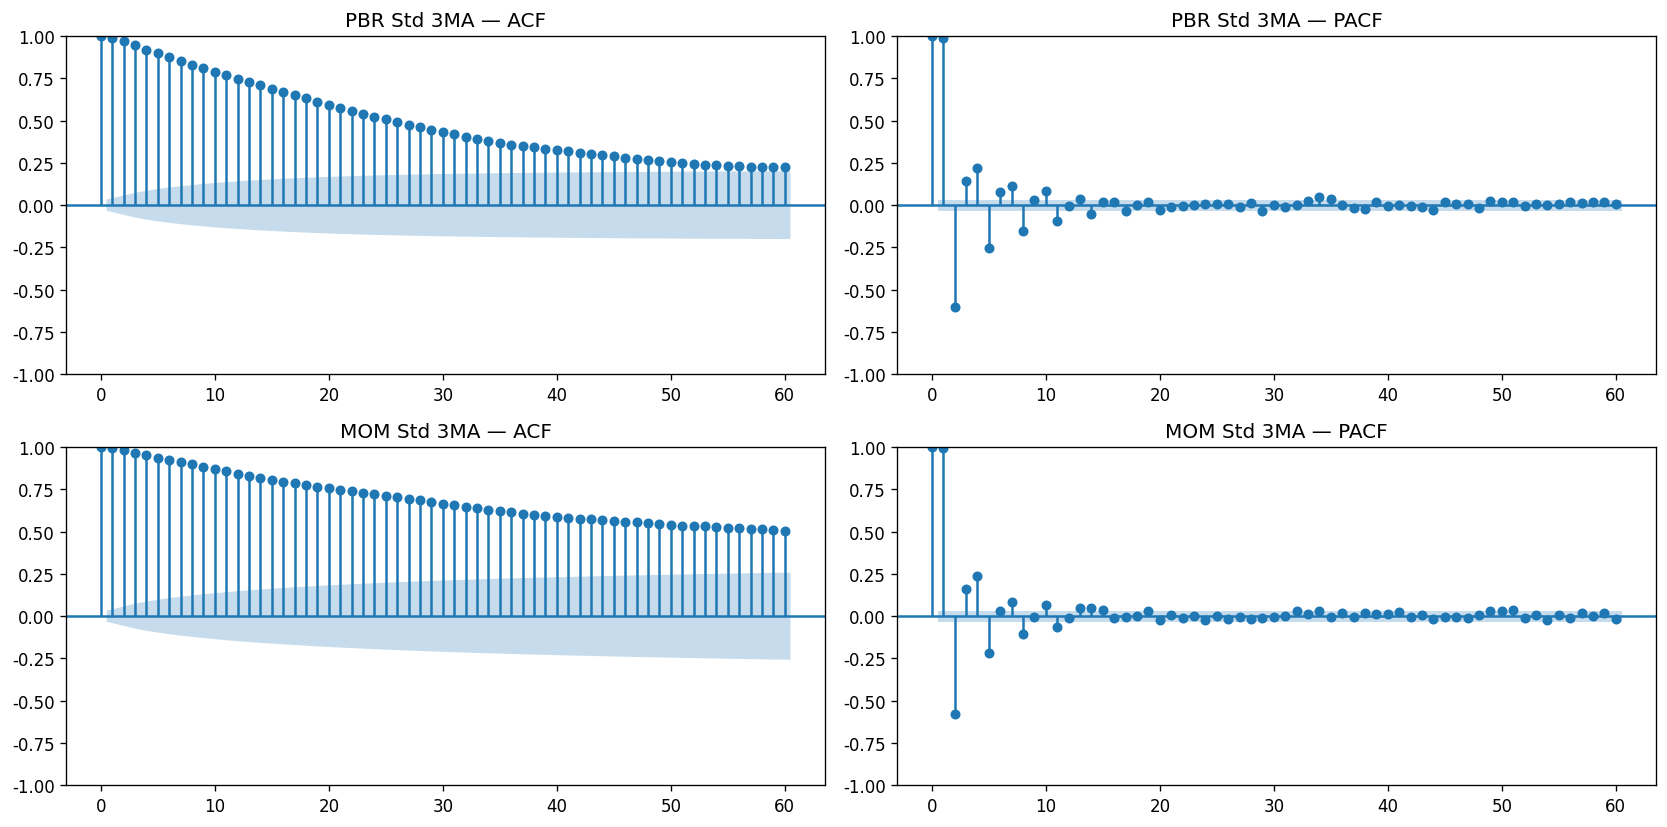

※ 3MA 적용으로 ACF 감소가 더 느려짐 → 강한 추세 구조


In [7]:
# ACF / PACF (3MA 시리즈)
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for i, (series, name) in enumerate([(pbr_std, "PBR Std 3MA"), (mom_std, "MOM Std 3MA")]):
    s = series.dropna()
    plot_acf(s,  lags=60, ax=axes[i][0], title=f"{name} — ACF")
    plot_pacf(s, lags=60, ax=axes[i][1], title=f"{name} — PACF", method="ywm")

plt.tight_layout()
plt.show()
print("※ 3MA 적용으로 ACF 감소가 더 느려짐 → 강한 추세 구조")

## 3. ARCH 효과 검정

> GARCH 모델의 핵심 전제: **잔차의 제곱이 자기상관**을 가져야 함 (= 변동성 클러스터링)
>
> 전략: AR(1) 평균 모형으로 선형 추세를 제거 → 잔차에 Engle's ARCH-LM 검정
>
> - H0: ARCH 효과 없음 / p < 0.05 → GARCH 모델 적합 의미 있음

In [8]:
from statsmodels.tsa.ar_model import AutoReg

def arch_lm_report(series: pd.Series, name: str, lags: int = 10):
    s = series.dropna()
    ar_fit = AutoReg(s, lags=1, old_names=False).fit()
    resid  = ar_fit.resid.dropna()
    lm_stat, lm_p, f_stat, f_p = het_arch(resid, nlags=lags)
    print(f"[{name}]")
    print(f"  AR(1) 잔차: mean={resid.mean():.4f}, std={resid.std():.4f}")
    print(f"  ARCH-LM (lag={lags}): LM={lm_stat:.4f}, p={lm_p:.4f}  "
          f"{'→ ARCH 효과 있음 ✓' if lm_p < 0.05 else '→ ARCH 효과 없음 ✗'}")
    print()
    return resid

resid_pbr = arch_lm_report(pbr_std, "PBR Std 3MA")
resid_mom = arch_lm_report(mom_std, "MOM Std 3MA")

[PBR Std 3MA]
  AR(1) 잔차: mean=-0.0000, std=0.0430
  ARCH-LM (lag=10): LM=1626.2850, p=0.0000  → ARCH 효과 있음 ✓

[MOM Std 3MA]
  AR(1) 잔차: mean=0.0000, std=0.0362
  ARCH-LM (lag=10): LM=879.2492, p=0.0000  → ARCH 효과 있음 ✓



/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


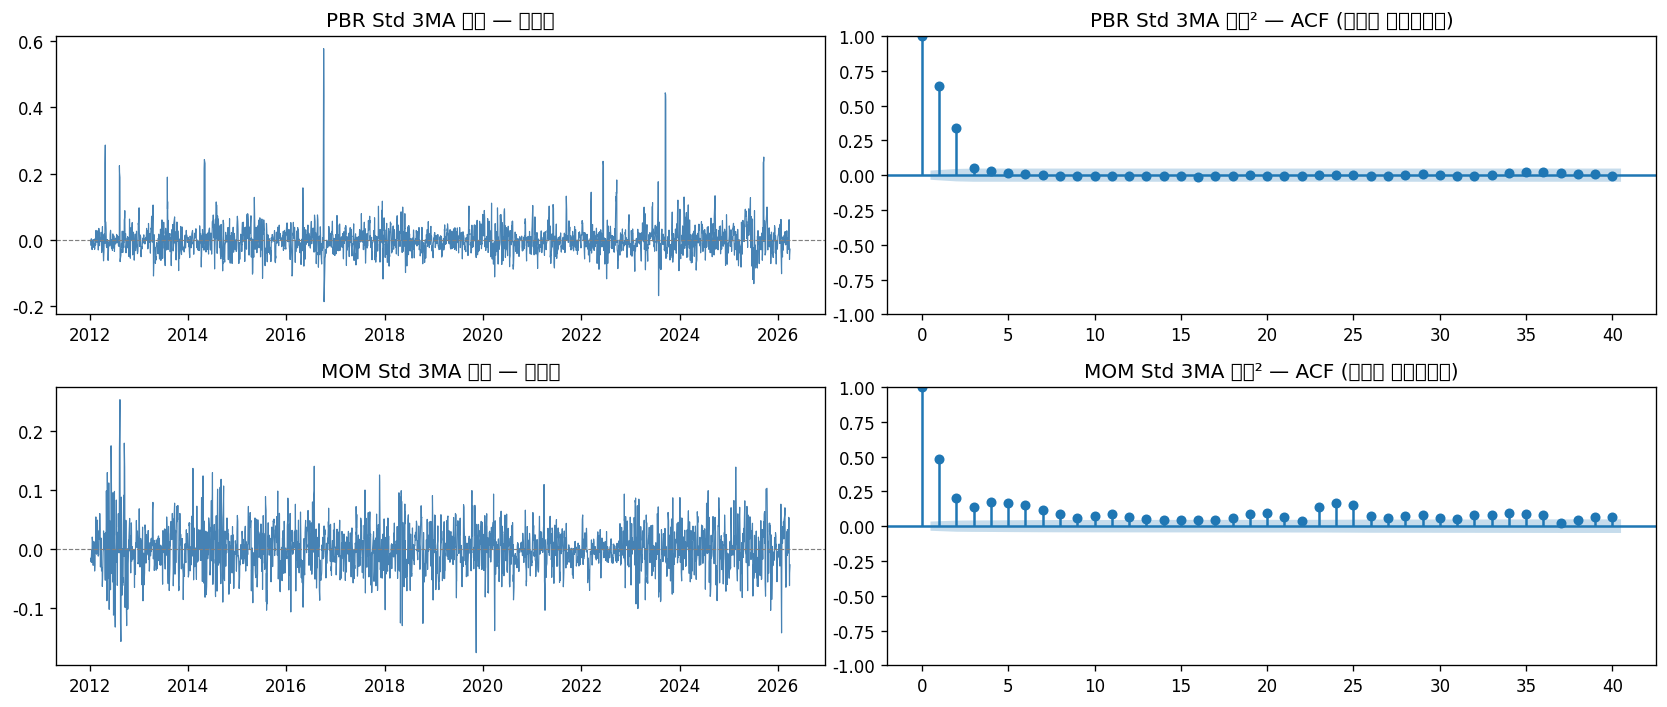

※ 잔차² ACF 유의 → GARCH 모델 적합 의미 있음


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

for i, (resid, name) in enumerate([(resid_pbr, "PBR Std 3MA 잔차"), (resid_mom, "MOM Std 3MA 잔차")]):
    axes[i][0].plot(resid.index, resid.values, linewidth=0.7, color="steelblue")
    axes[i][0].set_title(f"{name} — 시계열")
    axes[i][0].axhline(0, color="gray", linestyle="--", linewidth=0.7)
    plot_acf(resid**2, lags=40, ax=axes[i][1], title=f"{name}² — ACF (변동성 클러스터링)")

plt.tight_layout()
plt.show()
print("※ 잔차² ACF 유의 → GARCH 모델 적합 의미 있음")

## 4. GARCH(1,1) 모델 적합

> **평균 방정식**: AR(1) (수준 시리즈의 강한 자기상관을 흡수)
>
> **분산 방정식**: GARCH(1,1) — σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}
>
> - α (ARCH 항): 전일 충격이 오늘 변동성에 미치는 영향
> - β (GARCH 항): 전일 변동성이 오늘 변동성으로 이어지는 지속성
> - α + β < 1 이어야 안정적 (값이 1에 가까울수록 변동성 지속성 강함)

In [10]:
def fit_garch(series: pd.Series, name: str):
    s = series.dropna() * 100
    model = arch_model(s, mean="ARX", lags=1, vol="GARCH", p=1, q=1, dist="normal")
    result = model.fit(disp="off", show_warning=False)

    print(f"{'='*55}")
    print(f"  GARCH(1,1) — {name}")
    print(f"{'='*55}")
    params = result.params
    pvals  = result.pvalues
    for pname in ["Const", "x[1]", "omega", "alpha[1]", "beta[1]"]:
        if pname in params.index:
            star = "***" if pvals[pname] < 0.01 else ("**" if pvals[pname] < 0.05 else ("*" if pvals[pname] < 0.1 else ""))
            print(f"  {pname:12s}: {params[pname]:10.5f}  (p={pvals[pname]:.4f}) {star}")

    alpha = params.get("alpha[1]", float('nan'))
    beta  = params.get("beta[1]",  float('nan'))
    print(f"\n  α + β = {alpha + beta:.5f}  {'← 안정적' if alpha + beta < 1 else '← 불안정'}")
    print(f"  AIC={result.aic:.1f}  BIC={result.bic:.1f}  LogL={result.loglikelihood:.1f}")
    print()
    return result, s

garch_pbr, s_pbr = fit_garch(pbr_std, "PBR Std 3MA")
garch_mom, s_mom = fit_garch(mom_std, "MOM Std 3MA")

  GARCH(1,1) — PBR Std 3MA
  Const       :    1.69565  (p=0.0002) ***
  omega       :    8.57927  (p=0.0000) ***
  alpha[1]    :    0.49341  (p=0.0000) ***
  beta[1]     :    0.00000  (p=1.0000) 

  α + β = 0.49341  ← 안정적
  AIC=18829.2  BIC=18860.0  LogL=-9409.6

  GARCH(1,1) — MOM Std 3MA
  Const       :    0.47080  (p=0.0015) ***
  omega       :    1.71217  (p=0.0000) ***
  alpha[1]    :    0.39657  (p=0.0000) ***
  beta[1]     :    0.50487  (p=0.0000) ***

  α + β = 0.90144  ← 안정적
  AIC=18051.3  BIC=18082.1  LogL=-9020.6



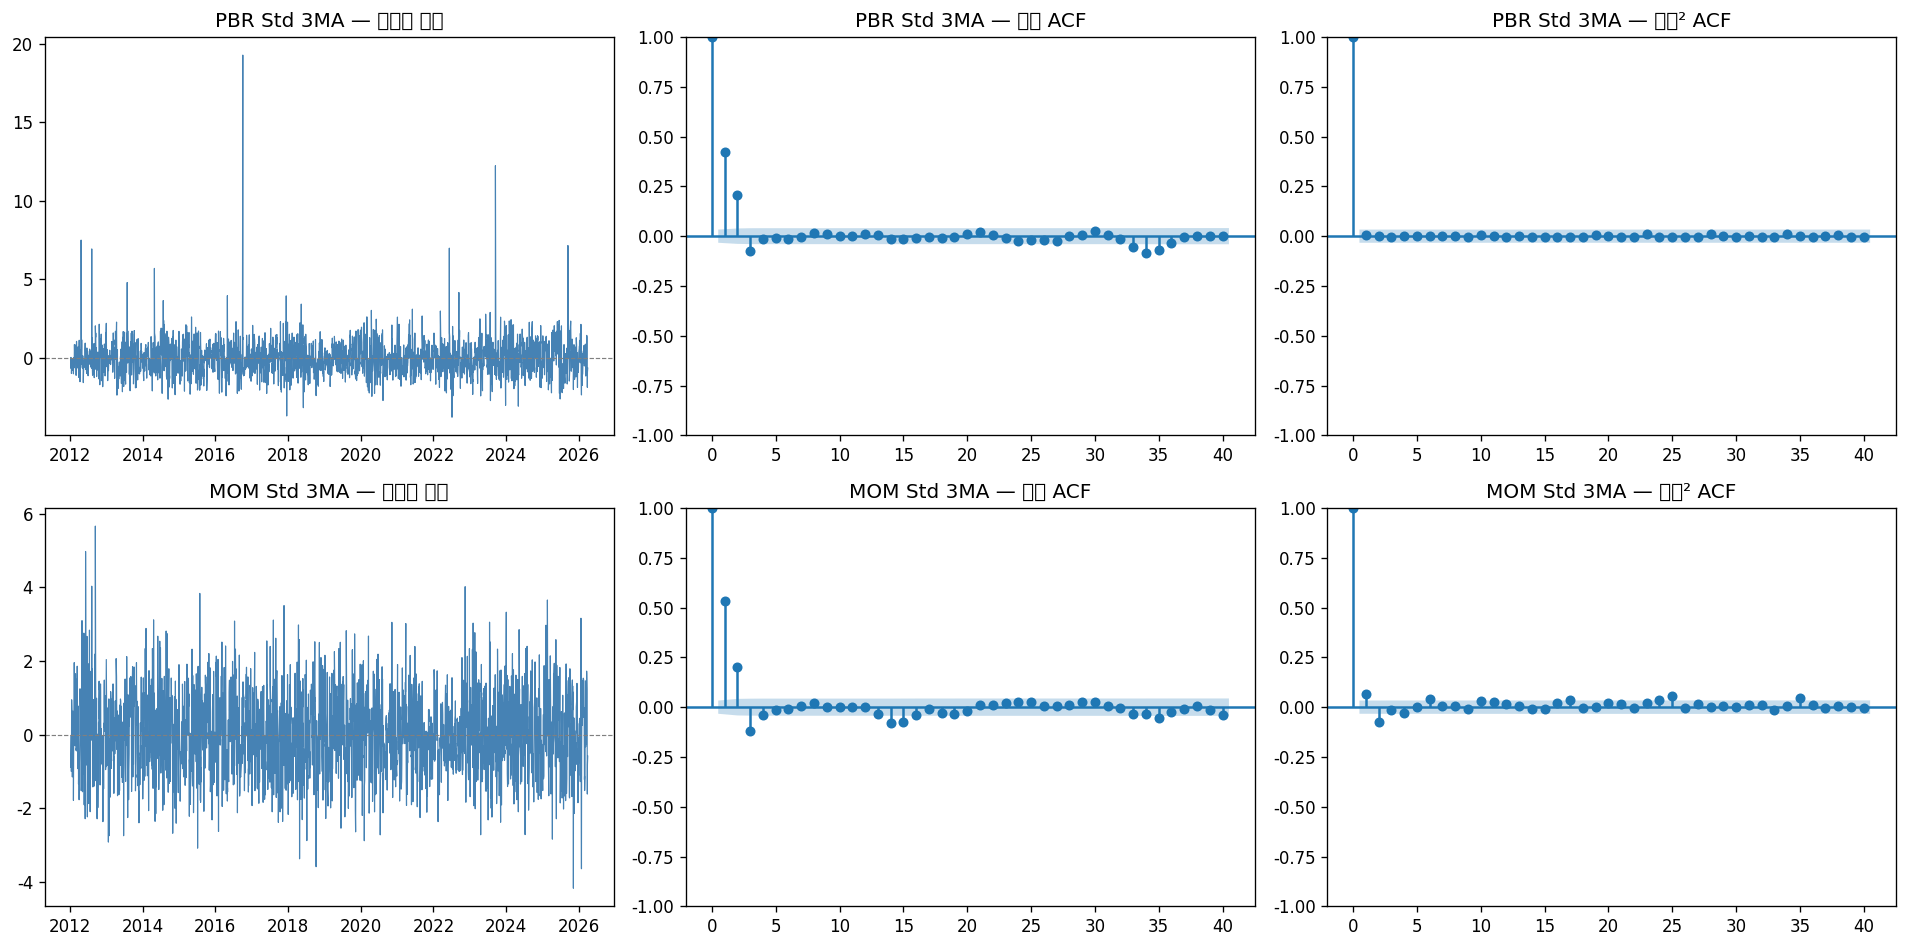

※ 잔차² ACF가 신뢰구간 내 → GARCH가 변동성 클러스터링 잘 흡수


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (result, s, name) in enumerate([
    (garch_pbr, s_pbr, "PBR Std 3MA"),
    (garch_mom, s_mom, "MOM Std 3MA"),
]):
    std_resid = result.std_resid.dropna()
    axes[row][0].plot(std_resid.index, std_resid.values, linewidth=0.7, color="steelblue")
    axes[row][0].set_title(f"{name} — 표준화 잔차")
    axes[row][0].axhline(0, color="gray", linestyle="--", linewidth=0.7)
    plot_acf(std_resid,    lags=40, ax=axes[row][1], title=f"{name} — 잔차 ACF")
    plot_acf(std_resid**2, lags=40, ax=axes[row][2], title=f"{name} — 잔차² ACF")

plt.tight_layout()
plt.show()
print("※ 잔차² ACF가 신뢰구간 내 → GARCH가 변동성 클러스터링 잘 흡수")

## 5. 롤링 예측 (Walk-Forward Validation)

> - Train: 전체 데이터의 앞 80%
> - Test: 나머지 20% 구간에서 **1-step-ahead 롤링 예측**
> - 조건부 평균(μ̂)과 조건부 표준편차(σ̂)를 각각 평가

In [12]:
def rolling_garch_forecast(series_scaled: pd.Series, train_ratio: float = 0.8):
    n_train = int(len(series_scaled) * train_ratio)
    pred_mean, pred_vol, actual, dates = [], [], [], []

    for t in range(n_train, len(series_scaled)):
        train = series_scaled.iloc[:t]
        m = arch_model(train, mean="ARX", lags=1, vol="GARCH", p=1, q=1, dist="normal")
        res = m.fit(disp="off", show_warning=False, last_obs=len(train))
        fc  = res.forecast(horizon=1, reindex=False)
        pred_mean.append(fc.mean.iloc[-1, 0])
        pred_vol.append(np.sqrt(fc.variance.iloc[-1, 0]))
        actual.append(series_scaled.iloc[t])
        dates.append(series_scaled.index[t])
        if (t - n_train) % 50 == 0:
            print(f"  진행: {t - n_train}/{len(series_scaled) - n_train} steps", end="\r")

    print(f"\n  완료.")
    idx = pd.DatetimeIndex(dates)
    return (
        pd.Series(pred_mean, index=idx, name="pred_mean"),
        pd.Series(pred_vol,  index=idx, name="pred_vol"),
        pd.Series(actual,    index=idx, name="actual"),
    )

print("PBR Std 3MA 롤링 예측 중...")
pm_pbr, pv_pbr, act_pbr = rolling_garch_forecast(s_pbr)

print("\nMOM Std 3MA 롤링 예측 중...")
pm_mom, pv_mom, act_mom = rolling_garch_forecast(s_mom)

PBR Std 3MA 롤링 예측 중...



  완료.

MOM Std 3MA 롤링 예측 중...



  완료.


In [13]:
# 예측 성과 평가 — 3MA 예측값 vs 실제 일별 STD (raw)
# 핵심 질문: 3MA 기반 GARCH가 raw 일별 STD의 방향을 맞추는가?

def eval_vs_raw(pred_mean_scaled, raw_std, name):
    # pred: 3MA GARCH 예측 (×100 스케일), raw: 실제 일별 STD
    pred = pred_mean_scaled / 100  # 스케일 복원
    raw  = raw_std.reindex(pred.index).dropna()
    pred = pred.reindex(raw.index)

    # 방향성 평가: 전일 대비 raw STD 변화 방향 vs 예측 변화 방향
    raw_dir  = np.sign(raw.diff().dropna())
    pred_dir = np.sign(pred.diff().dropna())
    aligned  = raw_dir.index.intersection(pred_dir.index)
    dir_acc  = np.mean(raw_dir[aligned] == pred_dir[aligned])

    # 수준 상관 (추세 방향 일치도)
    corr = pred.corr(raw)

    # 고/저 국면 구분: raw STD가 중앙값 이상이면 High Dispersion
    median = raw.median()
    high_mask = raw[aligned] >= median
    dir_acc_high = np.mean(raw_dir[aligned][high_mask] == pred_dir[aligned][high_mask]) if high_mask.sum() > 0 else float('nan')
    dir_acc_low  = np.mean(raw_dir[aligned][~high_mask] == pred_dir[aligned][~high_mask]) if (~high_mask).sum() > 0 else float('nan')

    print(f"[{name}]  평가 기간: {raw.index.min().date()} ~ {raw.index.max().date()}  n={len(raw)}")
    print(f"  방향 정확도 (전체)           : {dir_acc:.1%}")
    print(f"  방향 정확도 (High Dispersion): {dir_acc_high:.1%}  ← 시장 스트레스 구간")
    print(f"  방향 정확도 (Low  Dispersion): {dir_acc_low:.1%}")
    print(f"  수준 상관계수 (pred vs raw)  : {corr:.4f}")
    print(f"  랜덤 기준선                  : 50.0%")
    is_useful = dir_acc > 0.52  # 통계적으로 의미 있는 임계
    print(f"  → {'유의미함 ✓' if is_useful else '유의미하지 않음 ✗'} (기준: >52%)")
    print()
    return pred, raw

pred_pbr, raw_pbr = eval_vs_raw(pm_pbr, pbr_std_raw, "PBR — 3MA GARCH → 일별 STD")
pred_mom, raw_mom = eval_vs_raw(pm_mom, mom_std_raw, "MOM — 3MA GARCH → 일별 STD")


[PBR — 3MA GARCH → 일별 STD]  평가 기간: 2023-05-15 ~ 2026-03-30  n=699
  방향 정확도 (전체)           : 47.6%
  방향 정확도 (High Dispersion): 46.3%  ← 시장 스트레스 구간
  방향 정확도 (Low  Dispersion): 48.9%
  수준 상관계수 (pred vs raw)  : 0.9305
  랜덤 기준선                  : 50.0%
  → 유의미하지 않음 ✗ (기준: >52%)

[MOM — 3MA GARCH → 일별 STD]  평가 기간: 2023-05-15 ~ 2026-03-30  n=699
  방향 정확도 (전체)           : 47.9%
  방향 정확도 (High Dispersion): 46.6%  ← 시장 스트레스 구간
  방향 정확도 (Low  Dispersion): 49.1%
  수준 상관계수 (pred vs raw)  : 0.9723
  랜덤 기준선                  : 50.0%
  → 유의미하지 않음 ✗ (기준: >52%)



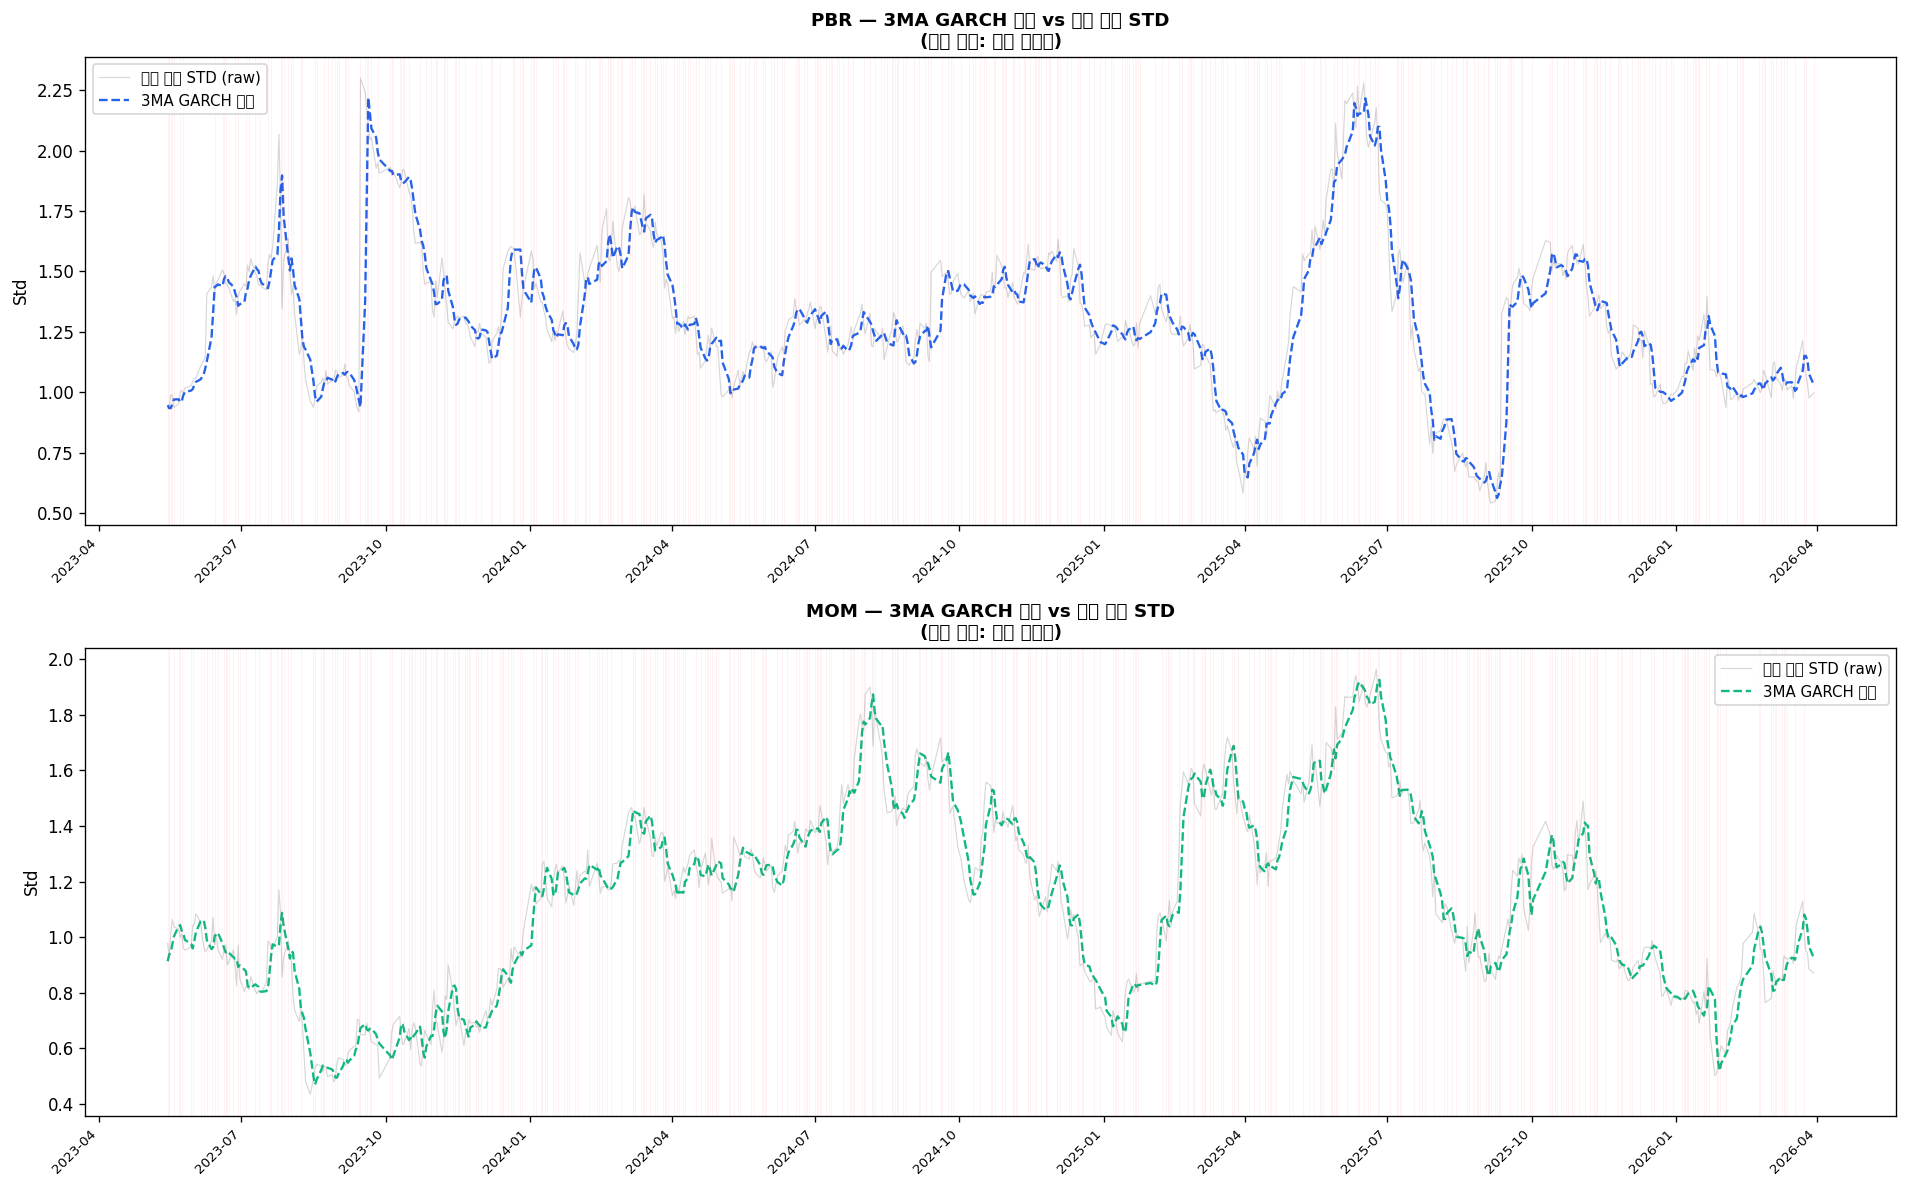

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, pred, raw, name, color in [
    (axes[0], pred_pbr, raw_pbr, "PBR — 3MA GARCH 예측 vs 실제 일별 STD", "#2563eb"),
    (axes[1], pred_mom, raw_mom, "MOM — 3MA GARCH 예측 vs 실제 일별 STD", "#10b981"),
]:
    ax.plot(raw.index,  raw.values,  linewidth=0.7, color="lightgray", label="실제 일별 STD (raw)", alpha=0.9)
    ax.plot(pred.index, pred.values, linewidth=1.4, color=color,       label="3MA GARCH 예측", linestyle="--")

    # 방향 일치/불일치 표시
    raw_dir  = np.sign(raw.diff())
    pred_dir = np.sign(pred.diff())
    match = (raw_dir == pred_dir).dropna()
    wrong_dates = match[~match].index
    for d in wrong_dates:
        ax.axvline(d, color="red", alpha=0.06, linewidth=0.5)

    ax.set_title(f"{name}\n(회색 배경: 방향 불일치)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Std")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()


## 6. 결론 및 해석 가이드

| 항목 | 확인 포인트 | 의미 |
|------|------------|------|
| ADF p-value | < 0.05 | 원본이 정상 → GARCH 직접 적용 가능 |
| ARCH-LM p-value | < 0.05 | 변동성 클러스터링 존재 → GARCH 의미 있음 |
| α + β | < 1, 가까울수록 | 변동성 충격이 오래 지속됨 |
| 잔차² ACF | 신뢰구간 내 | GARCH가 클러스터링을 잘 흡수 |
| 방향 정확도 | > 50% | 랜덤워크 대비 예측력 있음 |

### GARCH의 한계 & 다음 단계 아이디어
- GARCH는 **수준값(level) 예측보다 변동성(σ̂) 예측**에 강함 → `pred_vol`을 위험 신호로 활용
- AR(1) 평균 방정식이 강한 자기상관을 흡수하므로, 실질적 예측은 **t-1 값에 의존**
- 개선 방향:
  - `EGARCH` / `GJR-GARCH`: 비대칭 충격(하락 시 변동성 더 크게 반응)
  - `Student-t 분포`: 두꺼운 꼬리(fat tail) 반영
  - 외생변수(X) 추가: KOSPI 수익률, VIX 등을 평균 방정식에 투입

---
## 7. 주간 방향성 예측 — 3MA STD → 주간 GARCH(1,1)

> **질문**: 3MA STD를 주간 마지막 영업일로 리샘플한 뒤, GARCH(1,1)로 다음 주 방향(상승/하락)을 예측할 수 있는가?
>
> - 일별보다 노이즈가 줄어 방향성 신호가 더 명확해질 것으로 기대
> - 평가 지표: **방향 정확도** (다음 주 STD가 오를지 내릴지)
> - 기준선: 랜덤 50%, 이항검정으로 통계적 유의성 확인

In [15]:
# 3MA STD → 주간 마지막 영업일 리샘플
pbr_weekly = pbr_std.resample("W-FRI").last().dropna()
mom_weekly = mom_std.resample("W-FRI").last().dropna()

print(f"PBR 주간 시리즈: {pbr_weekly.index.min().date()} ~ {pbr_weekly.index.max().date()}, n={len(pbr_weekly)}")
print(f"MOM 주간 시리즈: {mom_weekly.index.min().date()} ~ {mom_weekly.index.max().date()}, n={len(mom_weekly)}")
print()
print(pbr_weekly.describe().rename("PBR Weekly").to_frame()
      .join(mom_weekly.describe().rename("MOM Weekly")))

PBR 주간 시리즈: 2012-01-13 ~ 2026-04-03, n=742
MOM 주간 시리즈: 2012-01-13 ~ 2026-04-03, n=742

       PBR Weekly  MOM Weekly
count  742.000000  742.000000
mean     1.149197    1.003447
std      0.316110    0.339345
min      0.459027    0.187420
25%      0.945535    0.776809
50%      1.133242    0.997269
75%      1.337010    1.236395
max      2.348265    1.941586


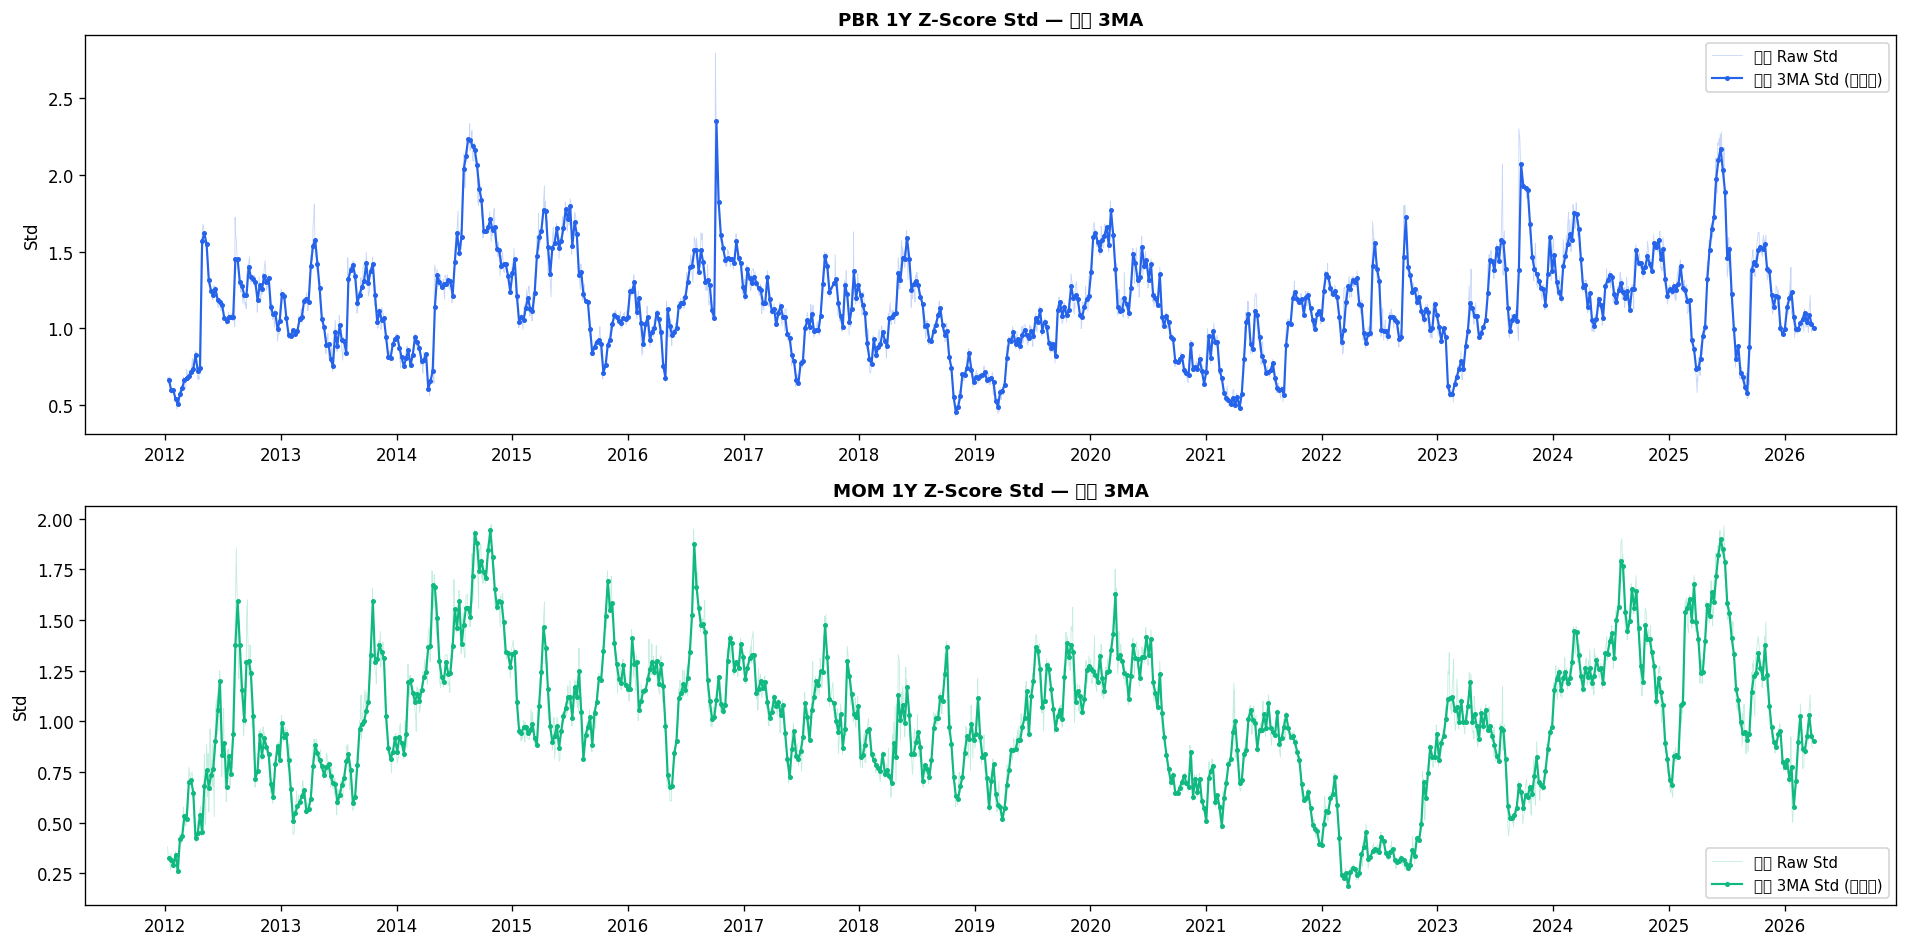

In [16]:
# 주간 시계열 시각화 — raw daily std 배경 + 주간 3MA 포인트
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, raw, weekly, color, label in [
    (axes[0], pbr_std_raw, pbr_weekly, "#2563eb", "PBR"),
    (axes[1], mom_std_raw, mom_weekly, "#10b981", "MOM"),
]:
    ax.plot(raw.index,    raw.values,    linewidth=0.5, color=color, alpha=0.25, label="일별 Raw Std")
    ax.plot(weekly.index, weekly.values, linewidth=1.3, color=color, marker="o", markersize=2, label="주간 3MA Std (금요일)")
    ax.set_title(f"{label} 1Y Z-Score Std — 주간 3MA", fontsize=11, fontweight="bold")
    ax.set_ylabel("Std")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

In [17]:
# 1Y Train / 1M Test Rolling GARCH — 방향성 평가
# - Train window : 이전 52주 (1년) 고정
# - Forecast     : 이후 4주 (1개월) 멀티스텝
# - 슬라이딩     : 4주씩 이동 (1개월마다 재학습)

from scipy.stats import binomtest

TRAIN_WEEKS  = 52   # 1년
TEST_WEEKS   = 4    # 1개월

def rolling_1y1m_direction(weekly: pd.Series, name: str):
    s = weekly.dropna() * 100
    n = len(s)

    pred_dir_list, actual_dir_list, dates = [], [], []

    t = TRAIN_WEEKS
    while t + TEST_WEEKS <= n:
        train = s.iloc[t - TRAIN_WEEKS : t]   # 이전 52주

        m   = arch_model(train, mean="ARX", lags=1, vol="GARCH", p=1, q=1, dist="normal")
        res = m.fit(disp="off", show_warning=False)
        fc  = res.forecast(horizon=TEST_WEEKS, reindex=False)

        pred_means = fc.mean.iloc[-1].values   # 4주 예측값 (스케일 그대로)

        for k in range(TEST_WEEKS):
            if t + k >= n:
                break
            prev_val   = s.iloc[t + k - 1]
            pred_next  = pred_means[k]
            actual_next = s.iloc[t + k]

            pred_dir_list.append(int(np.sign(pred_next - prev_val)))
            actual_dir_list.append(int(np.sign(actual_next - prev_val)))
            dates.append(s.index[t + k])

        t += TEST_WEEKS  # 4주 슬라이딩

    idx = pd.DatetimeIndex(dates)
    pred_dir   = pd.Series(pred_dir_list,   index=idx, name="pred_dir")
    actual_dir = pd.Series(actual_dir_list, index=idx, name="actual_dir")

    # 평가
    mask      = (pred_dir != 0) & (actual_dir != 0)
    n_valid   = mask.sum()
    n_correct = (pred_dir[mask] == actual_dir[mask]).sum()
    dir_acc   = n_correct / n_valid
    bt        = binomtest(n_correct, n_valid, p=0.5, alternative="greater")

    print(f"[{name}]")
    print(f"  평가 기간   : {dates[0].date()} ~ {dates[-1].date()}")
    print(f"  총 예측 주수 : {n_valid}주  (Train={TRAIN_WEEKS}주, Test 단위={TEST_WEEKS}주)")
    print(f"  방향 정확도 : {dir_acc:.1%}  ({n_correct}/{n_valid})")
    print(f"  이항검정 p  : {bt.pvalue:.4f}  {'→ 통계적 유의 ✓' if bt.pvalue < 0.05 else '→ 유의하지 않음 ✗'}")
    print()
    return pred_dir, actual_dir

print("=== 1Y Train / 1M Test Rolling GARCH 방향성 ===\n")
pred_dir_pbr, act_dir_pbr = rolling_1y1m_direction(pbr_weekly, "PBR Std 주간")
pred_dir_mom, act_dir_mom = rolling_1y1m_direction(mom_weekly, "MOM Std 주간")


=== 1Y Train / 1M Test Rolling GARCH 방향성 ===



[PBR Std 주간]
  평가 기간   : 2013-01-11 ~ 2026-03-20
  총 예측 주수 : 688주  (Train=52주, Test 단위=4주)
  방향 정확도 : 53.3%  (367/688)
  이항검정 p  : 0.0431  → 통계적 유의 ✓



[MOM Std 주간]
  평가 기간   : 2013-01-11 ~ 2026-03-20
  총 예측 주수 : 688주  (Train=52주, Test 단위=4주)
  방향 정확도 : 51.2%  (352/688)
  이항검정 p  : 0.2837  → 유의하지 않음 ✗



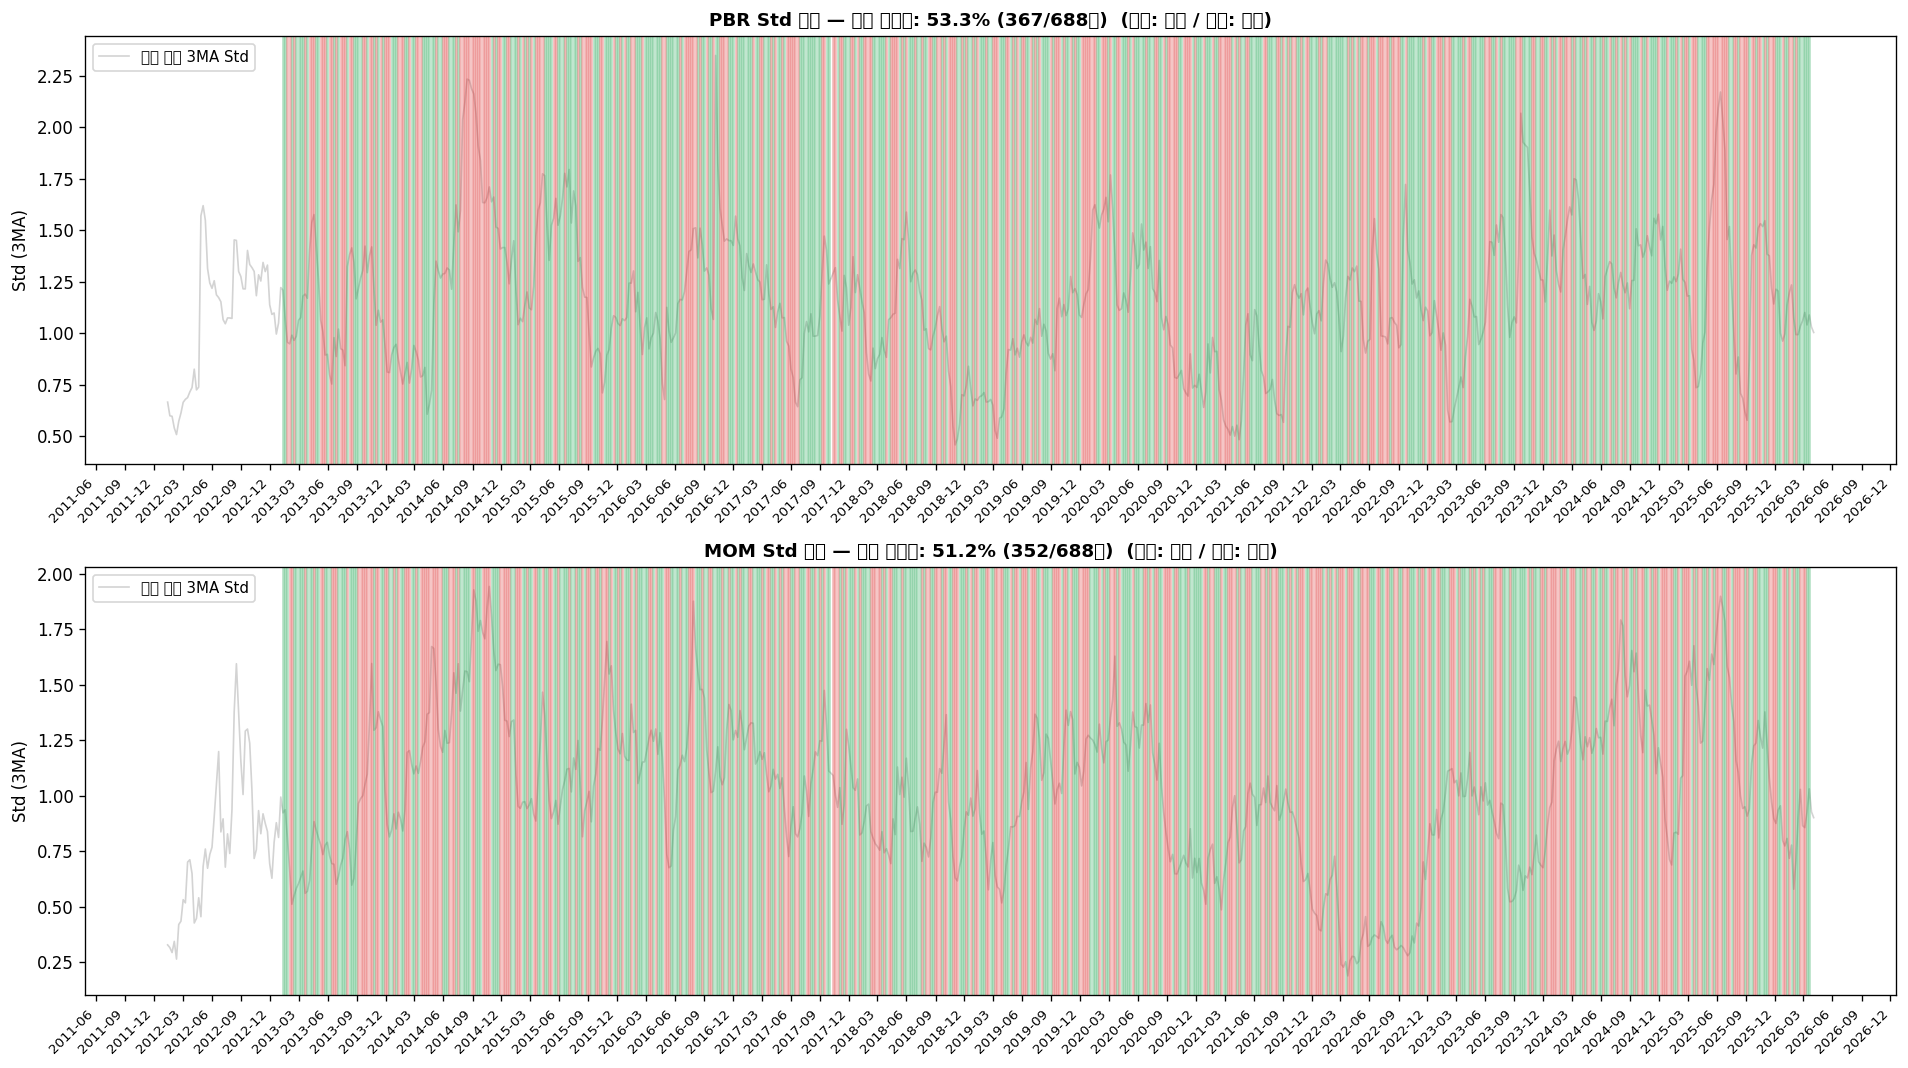

In [18]:
# 방향 정확도 시각화 — 맞은 주(초록) / 틀린 주(빨강) 표시
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

for ax, weekly, pred_dir, act_dir, color, name in [
    (axes[0], pbr_weekly, pred_dir_pbr, act_dir_pbr, "#2563eb", "PBR Std 주간"),
    (axes[1], mom_weekly, pred_dir_mom, act_dir_mom, "#10b981", "MOM Std 주간"),
]:
    ax.plot(weekly.index, weekly.values, linewidth=1.0, color="lightgray", label="실제 주간 3MA Std", zorder=1)

    mask = (pred_dir != 0) & (act_dir != 0)
    for d in pred_dir.index[mask]:
        c = "#16a34a" if pred_dir[d] == act_dir[d] else "#dc2626"
        ax.axvline(d, color=c, alpha=0.35, linewidth=1.5)

    n_correct = (pred_dir[mask] == act_dir[mask]).sum()
    n_total   = mask.sum()
    title_str = f"{name} — 방향 정확도: {n_correct/n_total:.1%} ({n_correct}/{n_total}주)  (초록: 맞음 / 빨강: 틀림)"
    ax.set_title(title_str, fontsize=11, fontweight="bold")
    ax.set_ylabel("Std (3MA)")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

### 7-2. 수치 예측 정확도 평가 (메인 지표)

> 방향성은 보조지표. **수치가 얼마나 잘 맞는지**가 핵심.
> - RMSE / MAE: 절대 오차
> - 상관계수: 예측-실제 추세 일치도
> - 예측 vs 실제 scatter plot + 시계열 비교

In [19]:
# 1Y Train / 1M Test Rolling GARCH — 수치 예측값 저장

TRAIN_WEEKS = 52
TEST_WEEKS  = 4

def rolling_1y1m_values(weekly: pd.Series, name: str):
    s = weekly.dropna() * 100
    n = len(s)

    pred_list, actual_list, vol_list, dates = [], [], [], []

    t = TRAIN_WEEKS
    while t + TEST_WEEKS <= n:
        train = s.iloc[t - TRAIN_WEEKS : t]

        m   = arch_model(train, mean="ARX", lags=1, vol="GARCH", p=1, q=1, dist="normal")
        res = m.fit(disp="off", show_warning=False)
        fc  = res.forecast(horizon=TEST_WEEKS, reindex=False)

        pred_means = fc.mean.iloc[-1].values
        pred_vols  = np.sqrt(fc.variance.iloc[-1].values)

        for k in range(TEST_WEEKS):
            if t + k >= n:
                break
            pred_list.append(pred_means[k])
            vol_list.append(pred_vols[k])
            actual_list.append(s.iloc[t + k])
            dates.append(s.index[t + k])

        t += TEST_WEEKS

        if (t - TRAIN_WEEKS) % 40 == 0:
            print(f"  {name} 진행: {t-TRAIN_WEEKS}/{n-TRAIN_WEEKS}", end="\r")

    print(f"  {name} 완료.    ")
    idx = pd.DatetimeIndex(dates)
    return (
        pd.Series(pred_list,   index=idx, name="pred")   / 100,
        pd.Series(actual_list, index=idx, name="actual") / 100,
        pd.Series(vol_list,    index=idx, name="vol")    / 100,
    )

print("=== 수치 예측값 저장 ===\n")
pv_pbr, av_pbr, vol_pbr = rolling_1y1m_values(pbr_weekly, "PBR Std 주간")
pv_mom, av_mom, vol_mom = rolling_1y1m_values(mom_weekly, "MOM Std 주간")


=== 수치 예측값 저장 ===



  PBR Std 주간 완료.    


  MOM Std 주간 완료.    


In [20]:
# 수치 정확도 지표 출력
from sklearn.metrics import mean_squared_error, mean_absolute_error

def numeric_eval(pred, actual, name):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    corr = pred.corr(actual)
    # 평균 대비 상대 오차 (MAPE 류)
    mape = (np.abs(actual - pred) / actual.abs().replace(0, np.nan)).mean()
    # 잔차 분포
    resid = actual - pred

    print(f"[{name}]")
    print(f"  평가 기간      : {actual.index.min().date()} ~ {actual.index.max().date()}  (n={len(actual)}주)")
    print(f"  실제값 범위    : [{actual.min():.4f}, {actual.max():.4f}]  mean={actual.mean():.4f}")
    print(f"  RMSE           : {rmse:.4f}  ({rmse/actual.mean()*100:.1f}% of mean)")
    print(f"  MAE            : {mae:.4f}  ({mae/actual.mean()*100:.1f}% of mean)")
    print(f"  MAPE           : {mape:.1%}")
    print(f"  상관계수       : {corr:.4f}")
    print(f"  잔차 std       : {resid.std():.4f}")
    print(f"  잔차 최대 절대값: {resid.abs().max():.4f}")
    print()

numeric_eval(pv_pbr, av_pbr, "PBR Std 주간 — GARCH 수치 예측")
numeric_eval(pv_mom, av_mom, "MOM Std 주간 — GARCH 수치 예측")


[PBR Std 주간 — GARCH 수치 예측]
  평가 기간      : 2013-01-11 ~ 2026-03-20  (n=688주)
  실제값 범위    : [0.4590, 2.3483]  mean=1.1549
  RMSE           : 0.2252  (19.5% of mean)
  MAE            : 0.1639  (14.2% of mean)
  MAPE           : 14.9%
  상관계수       : 0.7259
  잔차 std       : 0.2253
  잔차 최대 절대값: 1.1100

[MOM Std 주간 — GARCH 수치 예측]
  평가 기간      : 2013-01-11 ~ 2026-03-20  (n=688주)
  실제값 범위    : [0.1874, 1.9416]  mean=1.0199
  RMSE           : 0.1753  (17.2% of mean)
  MAE            : 0.1348  (13.2% of mean)
  MAPE           : 14.7%
  상관계수       : 0.8571
  잔차 std       : 0.1754
  잔차 최대 절대값: 0.5798



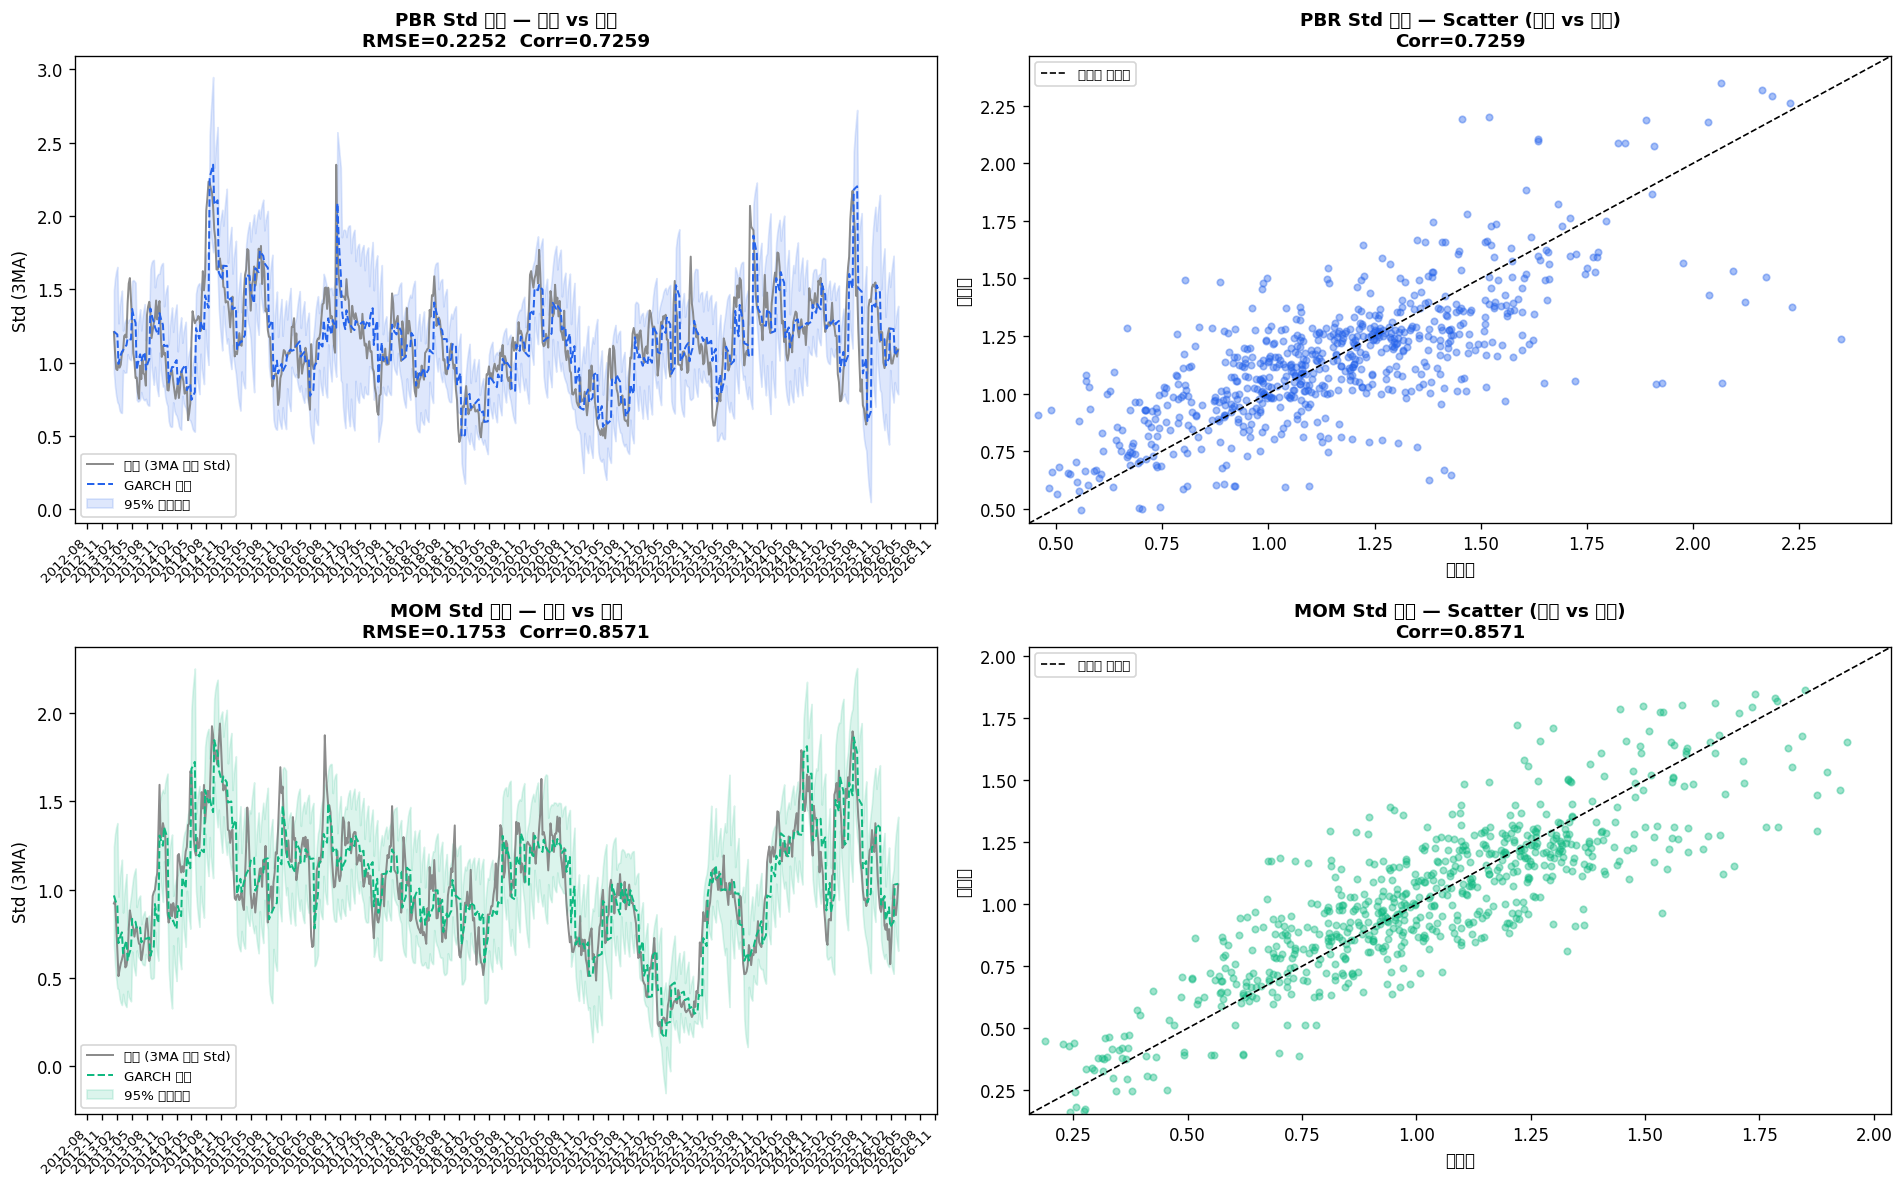

In [21]:
# 예측 vs 실제 시계열 비교 + Scatter Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (pred, actual, vol, name, color) in enumerate([
    (pv_pbr, av_pbr, vol_pbr, "PBR Std 주간", "#2563eb"),
    (pv_mom, av_mom, vol_mom, "MOM Std 주간", "#10b981"),
]):
    # 좌: 시계열 비교
    ax = axes[row][0]
    ax.plot(actual.index, actual.values, linewidth=1.2, color="gray",  label="실제 (3MA 주간 Std)", alpha=0.9)
    ax.plot(pred.index,   pred.values,   linewidth=1.2, color=color,   label="GARCH 예측", linestyle="--")
    ax.fill_between(
        pred.index,
        pred - 1.96 * vol,
        pred + 1.96 * vol,
        alpha=0.15, color=color, label="95% 예측구간"
    )
    rmse = np.sqrt(mean_squared_error(actual, pred))
    corr = pred.corr(actual)
    ax.set_title(f"{name} — 예측 vs 실제\nRMSE={rmse:.4f}  Corr={corr:.4f}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Std (3MA)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

    # 우: Scatter plot (예측 vs 실제)
    ax2 = axes[row][1]
    ax2.scatter(actual, pred, alpha=0.4, s=15, color=color)
    lim_min = min(actual.min(), pred.min()) * 0.95
    lim_max = max(actual.max(), pred.max()) * 1.05
    ax2.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, label="완벽한 예측선")
    ax2.set_xlabel("실제값")
    ax2.set_ylabel("예측값")
    ax2.set_title(f"{name} — Scatter (예측 vs 실제)\nCorr={corr:.4f}", fontsize=11, fontweight="bold")
    ax2.legend(fontsize=8)
    ax2.set_xlim(lim_min, lim_max)
    ax2.set_ylim(lim_min, lim_max)

plt.tight_layout()
plt.show()


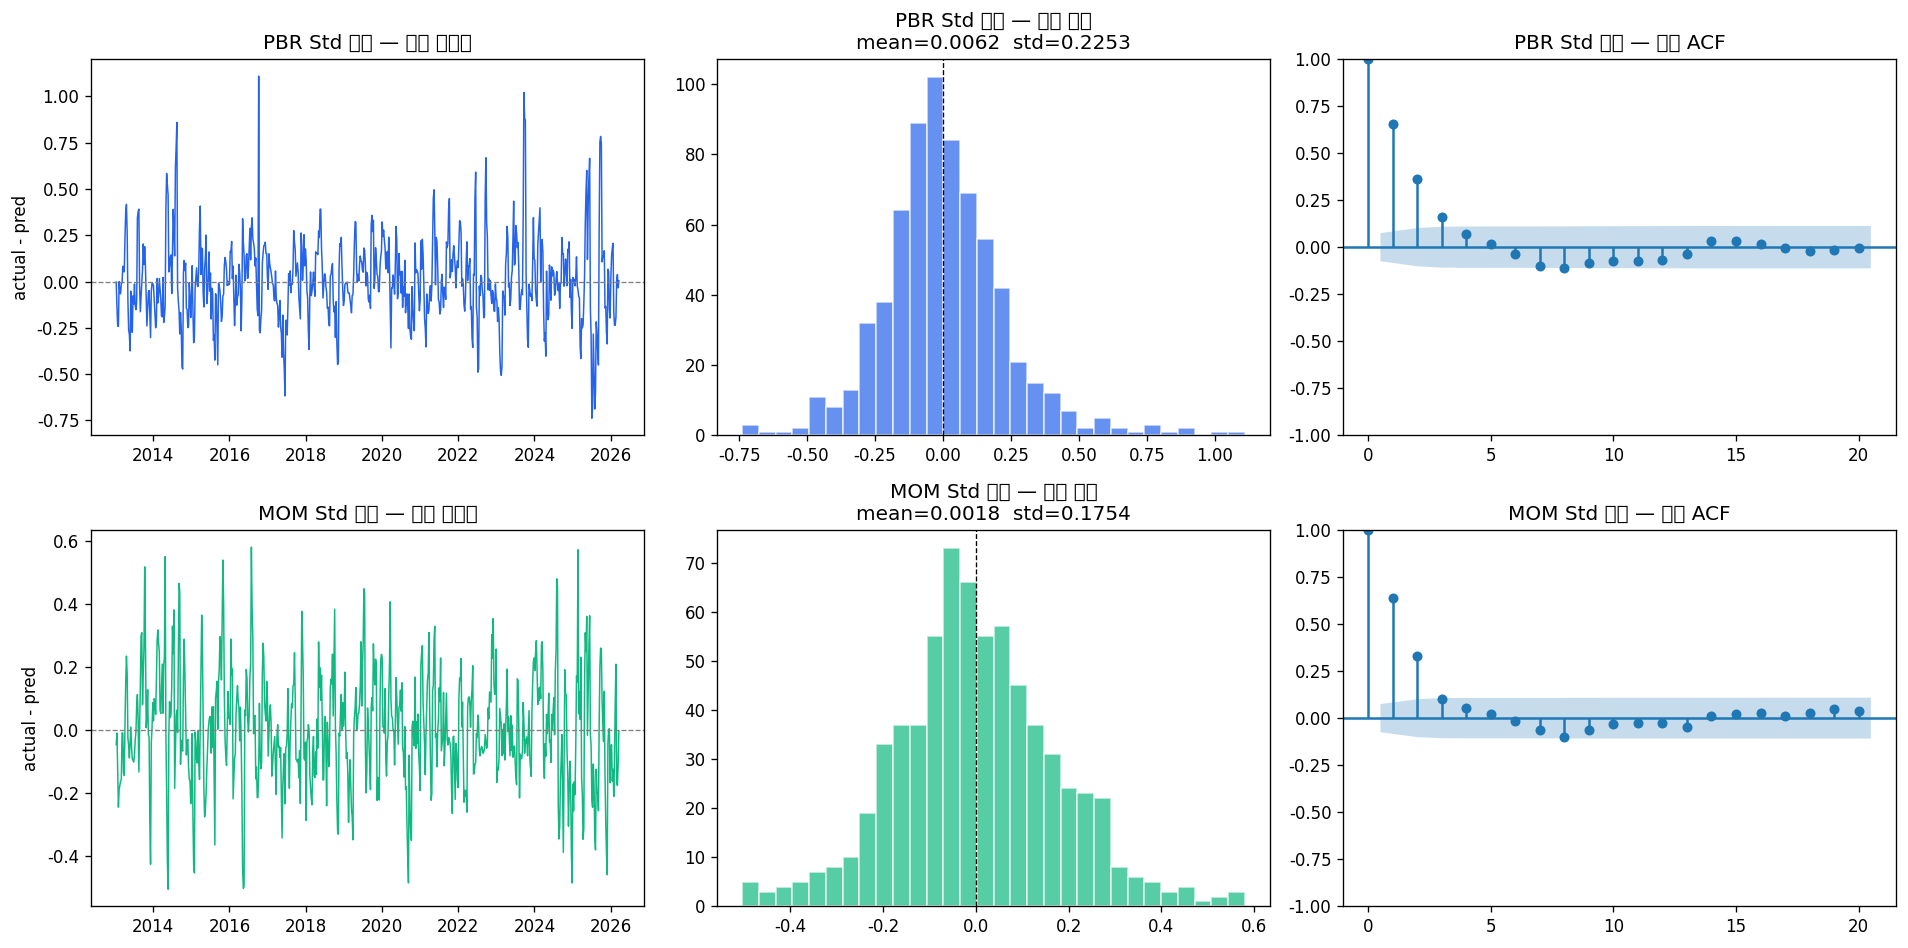

※ 잔차 ACF에 패턴이 남아있으면 GARCH 외 추가 구조(AR 차수, 계절성 등) 고려 필요


In [22]:
# 잔차(예측 오차) 분석
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (pred, actual, name, color) in enumerate([
    (pv_pbr, av_pbr, "PBR Std 주간", "#2563eb"),
    (pv_mom, av_mom, "MOM Std 주간", "#10b981"),
]):
    resid = actual - pred

    # 잔차 시계열
    axes[row][0].plot(resid.index, resid.values, linewidth=0.9, color=color)
    axes[row][0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[row][0].set_title(f"{name} — 잔차 시계열")
    axes[row][0].set_ylabel("actual - pred")

    # 잔차 히스토그램
    axes[row][1].hist(resid.dropna(), bins=30, color=color, alpha=0.7, edgecolor="white")
    axes[row][1].axvline(0, color="black", linestyle="--", linewidth=0.8)
    axes[row][1].set_title(f"{name} — 잔차 분포\nmean={resid.mean():.4f}  std={resid.std():.4f}")

    # 잔차 ACF (구조적 패턴 잔존 여부)
    plot_acf(resid.dropna(), lags=20, ax=axes[row][2], title=f"{name} — 잔차 ACF")

plt.tight_layout()
plt.show()
print("※ 잔차 ACF에 패턴이 남아있으면 GARCH 외 추가 구조(AR 차수, 계절성 등) 고려 필요")
